In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)

from src.utils import configure_logger

import pandas as pd

from typing import Any
from qqe.src.GNN.training.utils import collect_dataset_paths
from qqe.src.GNN.training.runners import MODEL_REGISTRY
from qqe.src.GNN.training.train_config import TrainConfig

from collections.abc import Callable
Loader = Callable[..., Any]

In [7]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

### Generate test dataset

In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from qqe.src.experiments.plotting import _plot_SRE_distribution
from qqe.src.GNN.dataset_builder import (
    DataGenConfig,
    RegimeDistribution,
    SamplingConfig,
    run_dataset_pipeline,
)
PROJECT_ROOT = Path().resolve().parent

In [ ]:
n_qubits = (4, 6, 8, 10)
n_layers = (1, 2, 4, 8, 16, 40, 50, 80, 100)
n_seeds = 50
output_dir = "../outputs/data/SRE_distributions/25_06_2026"

In [10]:
def default_sampling_config() -> SamplingConfig:
    return SamplingConfig(
        clifford=RegimeDistribution(
            regimes=["zero", "low", "medium", "high"],
            probabilities=[0.1, 0.4, 0.4, 0.1],
        ),
        random=RegimeDistribution(
            regimes=["identity_like", "clifford_like", "small_angles", "generic"],
            probabilities=[0.1, 0.4, 0.4, 0.1],
        ),
        quansistor=RegimeDistribution(
            regimes=[
                "identity_like",
                "weak",
                "moderate",
                "structured_equal_ab",
                "structured_opposite_ab",
                "generic_uniform",
            ],
            probabilities=[0.1, 0.4, 0.4, 0.1, 0.1, 0.1],
        ),
        haar=RegimeDistribution(
            regimes=["none", "sparse_weak", "dense_weak", "sparse_full", "medium", "full"],
            probabilities=[0.1, 0.4, 0.4, 0.1, 0.1, 0.1],
        ),
    )

In [28]:
def new_sampling_regimes() -> SamplingConfig:
    return SamplingConfig(
        clifford=RegimeDistribution(
            regimes=[
                "zero",
                "few",
                "low",
                "medium_low",
                "medium",
                "medium_high",
                "high",
            ],
            probabilities=[0.1, 0.3, 0.4, 0.1, 0.1, 0.1, 0.1],
        ),

        random=RegimeDistribution(
            regimes=[
                "identity_like",
                "near_clifford",
                "small_angles",
                "medium_angles",
                "generic_sparse",
                "generic_dense",
            ],
            probabilities=[0.25, 0.3, 0.25, 0.1, 0.1, 0.1],
        ),
        quansistor=RegimeDistribution(
            regimes=[
                "identity_like",
                "weak",
                "moderate",
                "structured_equal_ab",
                "structured_opposite_ab",
                "generic_uniform",
            ],
            probabilities=[0.1, 0.4, 0.4, 0.1, 0.1, 0.1],
        ),
        haar=RegimeDistribution(
            regimes=["none", "sparse_weak", "dense_weak", "sparse_full", "medium", "full"],
            probabilities=[0.1, 0.4, 0.4, 0.1, 0.1, 0.1],
        ),
    )

In [29]:
def make_dataset_loaders(
    model_type: str,
    epochs: int,
    lr: float,
    loss_type: str,
    batch_size: int,
    training_mode: str,
    family: str,
    target: str,
    data_dir: str,
    model_save_path: str,
    show_progress: bool = True,
    show_val_progress: bool = False,
    log_every_n_batches: int = 10,
    heartbeat_secs: float = 60.0,
    epoch_time_warning_secs: float = 600.0,
):
    cfg = TrainConfig(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        show_progress=show_progress,
        show_val_progress=show_val_progress,
        log_batch_loss_every=log_every_n_batches,
        heartbeat=heartbeat_secs,
        epoch_warning=epoch_time_warning_secs,
    )

    train_paths = collect_dataset_paths(
        data_dir,
        family=family if training_mode == "per_family" else None,
        split="target",
    )
    if not train_paths:
        raise RuntimeError("No data paths found.")
    logger.info(f"Found {len(train_paths)} data paths.")
    logger.info("Data paths collected.")

    spec = MODEL_REGISTRY[model_type]
    logger.info(f"Building loaders and model for model_type={model_type}...")

    loader_fn: Loader = spec["build_loaders"]
    returns_nodes_dim: bool = spec.get("returns_nodes_dim", False)
    if returns_nodes_dim:
        train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = loader_fn(
            train_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family,
        )
    else:
        train_loader, val_loader, test_loader, global_in_dim, base_dataset = loader_fn(
            train_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family,
        )
        node_in_dim = global_in_dim

    return train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset

In [30]:
cliff_config = DataGenConfig(
    backend="pennylane",
    method="fwht",
    families=["random", "clifford", "haar", "quansistor"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    prediction_n_seeds = None,
    n_bins=50,
    compute_sre=True,
    compute_EE=False,
    target_qubits=(4,6,8),
    representation="dense",
    use_dask=True,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    output_dir=Path(output_dir),
    max_configs=None,
)

run_dataset_pipeline(
    config=cliff_config,
    families=["random", "clifford", "haar", "quansistor"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=cliff_config.n_seeds,
    use_dask=True,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    sampling_config=new_sampling_regimes(),
)

2026-05-25 10:30:42,997 - qqe.src.GNN.dataset_builder - INFO - Processing family: random
2026-05-25 10:30:43,002 - qqe.src.GNN.dataset_builder - INFO - Generated 1800 configs for random
2026-05-25 10:30:43,002 - qqe.src.parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-05-25 10:30:43,020 - distributed.scheduler - INFO - State start
2026-05-25 10:30:43,040 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:53218
2026-05-25 10:30:43,041 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-05-25 10:30:43,041 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-05-25 10:30:43,105 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:53223'
2026-05-25 10:30:43,108 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:53225'
2026-05-25 10:30:43,110 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:53221'
2026-05-25 10:30:43,113 - 

2026-05-25 10:30:43,976 - distributed.scheduler - INFO - Register worker addr: tcp://127.0.0.1:53239 name: 1
2026-05-25 10:30:43,976 - distributed.scheduler - INFO - Starting worker compute stream, tcp://127.0.0.1:53239
2026-05-25 10:30:43,977 - distributed.core - INFO - Starting established connection to tcp://127.0.0.1:53244
2026-05-25 10:30:43,987 - distributed.scheduler - INFO - Register worker addr: tcp://127.0.0.1:53240 name: 3
2026-05-25 10:30:43,988 - distributed.scheduler - INFO - Starting worker compute stream, tcp://127.0.0.1:53240
2026-05-25 10:30:43,989 - distributed.core - INFO - Starting established connection to tcp://127.0.0.1:53246
2026-05-25 10:30:44,021 - distributed.scheduler - INFO - Register worker addr: tcp://127.0.0.1:53241 name: 0
2026-05-25 10:30:44,022 - distributed.scheduler - INFO - Starting worker compute stream, tcp://127.0.0.1:53241
2026-05-25 10:30:44,023 - distributed.core - INFO - Starting established connection to tcp://127.0.0.1:53250
2026-05-25 10

### Check distribution

In [31]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd


def load_sre_dataset(root: str | Path) -> pd.DataFrame:
    root = Path(root)
    rows = []

    for path in root.rglob("*.pt"):
        try:
            payload = torch.load(path, map_location="cpu", weights_only=False)
        except Exception as exc:
            print(f"Could not load {path}: {exc}")
            continue

        meta = payload.get("meta", {})

        if "sre" not in payload:
            continue

        sre = float(payload["sre"])

        if not np.isfinite(sre):
            continue

        n_qubits = int(meta.get("n_qubits", -1))
        n_layers = int(meta.get("n_layers", -1))
        family = meta.get("family", "unknown")

        row = {
            "path": str(path),
            "family": family,
            "n_qubits": n_qubits,
            "n_layers": n_layers,
            "seed": int(meta.get("seed", -1)),
            "sre": sre,
            "sre_density": sre / n_qubits if n_qubits > 0 else np.nan,
            "regime": meta.get("regime", "unknown"),
        }

        controls = meta.get("sampling_controls", {})
        for k, v in controls.items():
            row[f"ctrl_{k}"] = v

        gate_counts = payload.get("gate_counts", {})
        for k, v in gate_counts.items():
            if isinstance(v, (int, float)):
                row[f"count_{k}"] = v

        rows.append(row)

    return pd.DataFrame(rows)

In [32]:
import matplotlib.pyplot as plt
import numpy as np


def plot_global_sre_distribution(df: pd.DataFrame, family: str, density: bool = True):
    sub = df[df["family"] == family].copy()

    col = "sre_density" if density else "sre"
    xlabel = "SRE / n_qubits" if density else "SRE"

    values = sub[col].dropna().to_numpy()

    plt.figure(figsize=(7, 4))
    plt.hist(values, bins=40, alpha=0.8)
    plt.xlabel(xlabel)
    plt.ylabel("Number of circuits")
    plt.title(f"{family}: global {xlabel} distribution")
    plt.tight_layout()
    plt.show()

def plot_sre_ecdf(df: pd.DataFrame, family: str, density: bool = True):
    sub = df[df["family"] == family].copy()

    col = "sre_density" if density else "sre"
    xlabel = "SRE / n_qubits" if density else "SRE"

    values = np.sort(sub[col].dropna().to_numpy())

    if len(values) == 0:
        print(f"No values for {family}")
        return

    y = np.arange(1, len(values) + 1) / len(values)

    plt.figure(figsize=(7, 4))
    plt.plot(values, y)
    plt.xlabel(xlabel)
    plt.ylabel("Cumulative fraction")
    plt.title(f"{family}: empirical CDF of {xlabel}")
    plt.tight_layout()
    plt.show()

def add_sre_bins(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    bins = [-1e-12, 1e-5, 0.05, 0.10, 0.20, 0.35, 0.50, 0.75, np.inf]
    labels = [
        "zero",
        "tiny",
        "very_low",
        "low",
        "medium_low",
        "medium",
        "high",
        "very_high",
    ]

    df["sre_bin"] = pd.cut(
        df["sre_density"],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )

    return df

def plot_sre_vs_layers(df: pd.DataFrame, family: str):
    sub = df[df["family"] == family].copy()

    plt.figure(figsize=(7, 4))
    plt.scatter(
        sub["n_layers"],
        sub["sre_density"],
        s=12,
        alpha=0.35,
    )
    plt.xlabel("Number of layers")
    plt.ylabel("SRE / n_qubits")
    plt.title(f"{family}: SRE density vs depth")
    plt.tight_layout()
    plt.show()

def plot_sre_by_qubits(df: pd.DataFrame, family: str):
    sub = df[df["family"] == family].copy()

    plt.figure(figsize=(7, 4))
    sub.boxplot(column="sre_density", by="n_qubits")
    plt.suptitle("")
    plt.title(f"{family}: SRE density by number of qubits")
    plt.xlabel("n_qubits")
    plt.ylabel("SRE / n_qubits")
    plt.tight_layout()
    plt.show()

In [33]:
print(f"Loading dataset from {output_dir}...")
df = load_sre_dataset(output_dir)

print(df.shape)
print(df[["family", "n_qubits", "n_layers", "sre", "sre_density"]].head())

Loading dataset from ../outputs/data/SRE_distributions/25_06_2026...
(4796, 525)
     family  n_qubits  n_layers           sre   sre_density
0  clifford         4       100  7.431949e-14  1.857987e-14
1  clifford         4       100  9.161800e-14  2.290450e-14
2  clifford         4       100  1.724145e+00  4.310362e-01
3  clifford         4       100  9.225868e-14  2.306467e-14
4  clifford         4       100  1.025096e-13  2.562741e-14


In [34]:
# df_qubits = df[df["n_qubits"] == 8].copy()
df_qubits = df.copy()

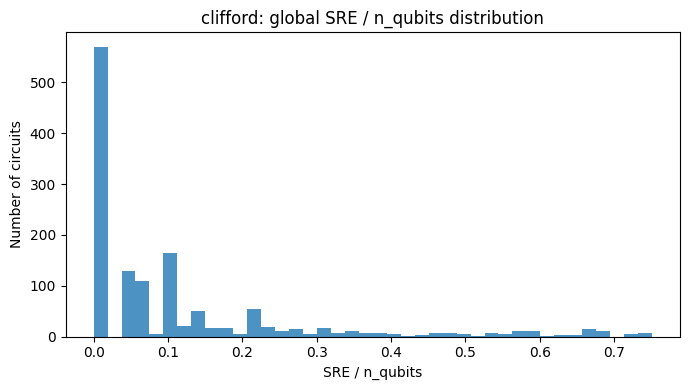

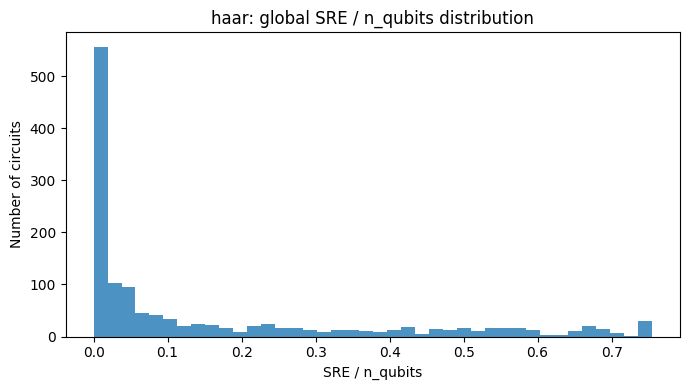

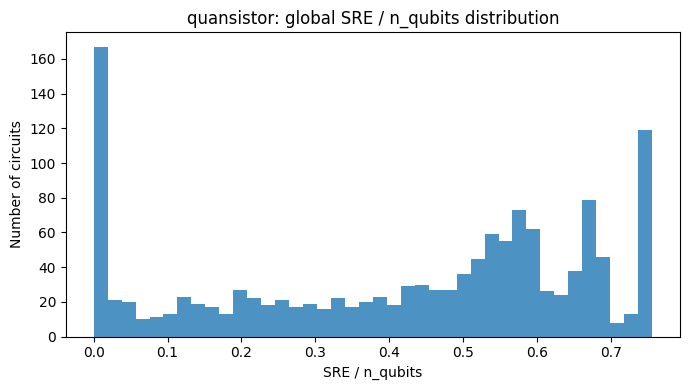

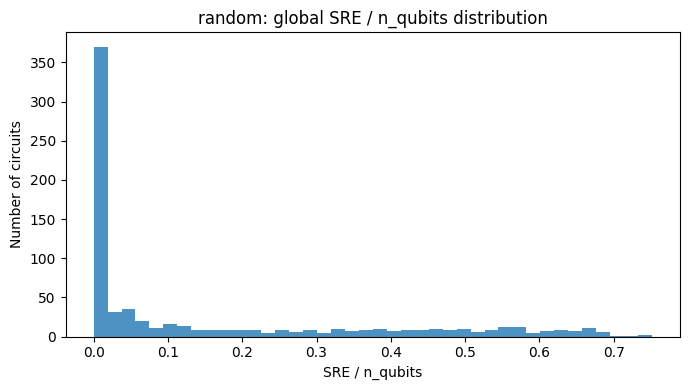

In [35]:
for family in sorted(df_qubits["family"].unique()):
    plot_global_sre_distribution(df_qubits, family, density=True)

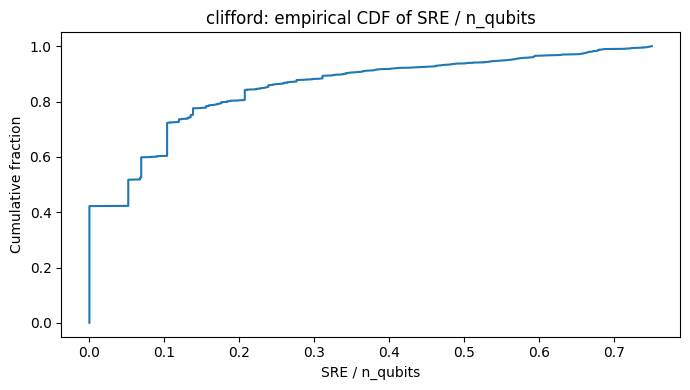

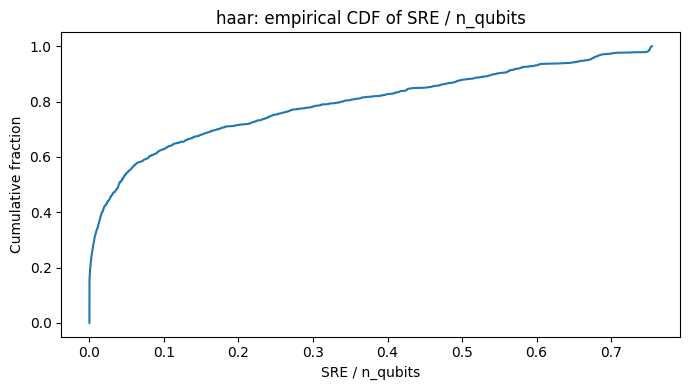

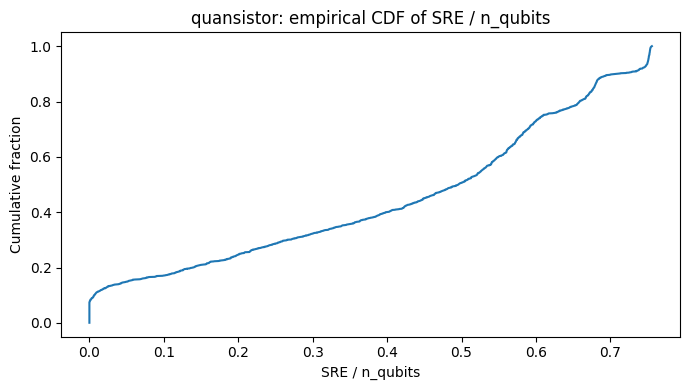

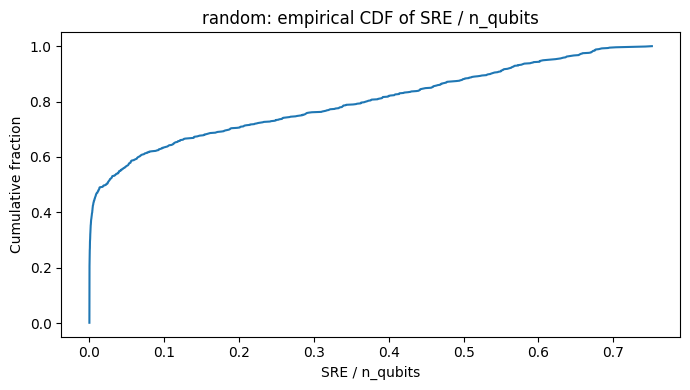

In [36]:
for family in sorted(df_qubits["family"].unique()):
    plot_sre_ecdf(df_qubits, family, density=True)

In [37]:
df_qubits = add_sre_bins(df_qubits)

coverage = (
    df_qubits.groupby("family")["sre_bin"]
      .value_counts(normalize=True)
      .rename("fraction")
      .reset_index()
)

print(coverage)

        family     sre_bin  fraction
0     clifford        zero  0.422222
1     clifford         low  0.201481
2     clifford    very_low  0.180741
3     clifford  medium_low  0.100000
4     clifford        high  0.061481
5     clifford      medium  0.032593
6     clifford   very_high  0.001481
7     clifford        tiny  0.000000
8         haar        tiny  0.388889
9         haar        zero  0.152593
10        haar        high  0.102963
11        haar  medium_low  0.089630
12        haar    very_low  0.086667
13        haar         low  0.086667
14        haar      medium  0.074074
15        haar   very_high  0.018519
16  quansistor        high  0.434074
17  quansistor      medium  0.148889
18  quansistor  medium_low  0.110370
19  quansistor         low  0.075556
20  quansistor        zero  0.074815
21  quansistor        tiny  0.074074
22  quansistor   very_high  0.060000
23  quansistor    very_low  0.022222
24      random        tiny  0.434316
25      random        zero  0.132708
2

In [ ]:
coverage_table = pd.crosstab(
    df_qubits["family"],
    df_qubits["sre_bin"],
    normalize="index",
)
print(coverage_table)

sre_bin         zero      tiny  very_low       low  medium_low    medium  \
family                                                                     
clifford    0.422222  0.000000  0.180741  0.201481     0.10000  0.032593   
haar        0.152593  0.388889  0.086667  0.086667     0.08963  0.074074   
quansistor  0.074815  0.074074  0.022222  0.075556     0.11037  0.148889   
random      0.132708  0.434316  0.067024  0.071046     0.08311  0.092493   

sre_bin         high  very_high  
family                           
clifford    0.061481   0.001481  
haar        0.102963   0.018519  
quansistor  0.434074   0.060000  
random      0.117962   0.001340  


### Clifford

In [39]:
def plot_clifford_sre_vs_tcount(df):
    sub = df[df["family"] == "clifford"].copy()
    sub["ctrl_t_count"] = pd.to_numeric(sub["ctrl_t_count"], errors="coerce")

    plt.figure(figsize=(7, 4))
    plt.scatter(
        sub["ctrl_t_count"],
        sub["sre"],
        s=12,
        alpha=0.35,
    )
    plt.fill_betweenx(
        y=[0, sub["sre"].max()],
        x1=0,
        x2=1,
        color="red",
        alpha=0.1,
        label="T count = 0",
    )
    plt.fill_betweenx(
        y=[0, sub["sre"].max()],
        x1=1,
        x2=2*sub["ctrl_t_count"].max()/50,
        color="green",
        alpha=0.1,
        label="T count = 0",
    )
    plt.fill_betweenx(
        y=[0, sub["sre"].max()],
        x1=2*sub["ctrl_t_count"].max()//50 + 1,
        x2=2*sub["ctrl_t_count"].max()//25,
        color="blue",
        alpha=0.1,
        label="T count = 0",
    )
    plt.fill_betweenx(
        y=[0, sub["sre"].max()],
        x1=2*sub["ctrl_t_count"].max()//25 + 1,
        x2=2*sub["ctrl_t_count"].max()//3,
        color="orange",
        alpha=0.1,
        label="T count = 0",
    )
    plt.xlabel("Requested T count")
    plt.ylabel("SRE / n_qubits")
    plt.title("Clifford: SRE density vs requested T count")
    plt.tight_layout()
    plt.show()

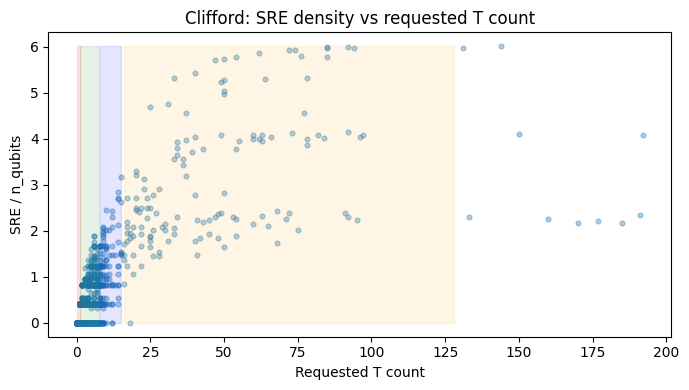

In [40]:
plot_clifford_sre_vs_tcount(df_qubits)

### Quansistor

In [41]:
def plot_quansistor_sre_controls(df):
    sub = df[df["family"] == "quansistor"].copy()

    sub["ctrl_gate_probability"] = pd.to_numeric(
        sub["ctrl_gate_probability"],
        errors="coerce",
    )
    sub["ctrl_param_scale"] = pd.to_numeric(
        sub["ctrl_param_scale"],
        errors="coerce",
    )

    plt.figure(figsize=(7, 4))
    plt.scatter(
        sub["ctrl_gate_probability"],
        sub["sre_density"],
        s=12,
        alpha=0.35,
    )
    plt.xlabel("gate_probability")
    plt.ylabel("SRE / n_qubits")
    plt.title("Quansistor: SRE density vs gate probability")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.scatter(
        sub["ctrl_param_scale"],
        sub["sre_density"],
        s=12,
        alpha=0.35,
    )
    plt.xlabel("param_scale")
    plt.ylabel("SRE / n_qubits")
    plt.title("Quansistor: SRE density vs param_scale")
    plt.tight_layout()
    plt.show()

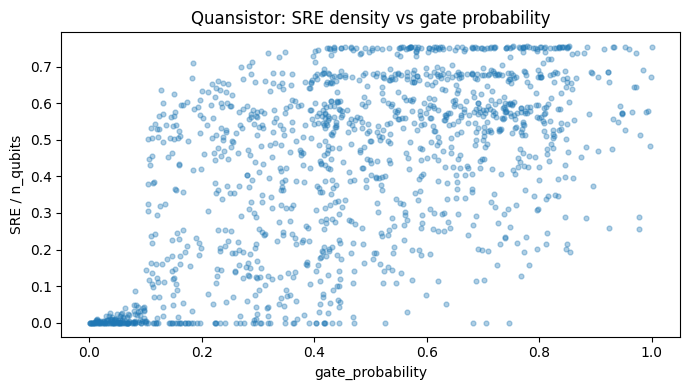

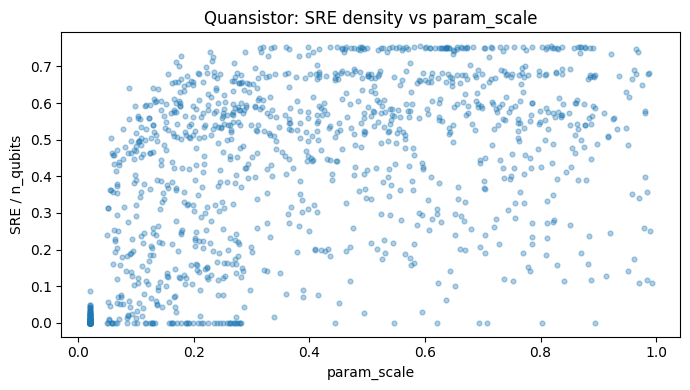

In [42]:
plot_quansistor_sre_controls(df_qubits)

### Haar

In [43]:
def plot_haar_sre_controls(df):
    sub = df[df["family"] == "haar"].copy()

    sub["ctrl_gate_probability"] = pd.to_numeric(
        sub["ctrl_gate_probability"],
        errors="coerce",
    )
    sub["ctrl_haar_strength"] = pd.to_numeric(
        sub["ctrl_haar_strength"],
        errors="coerce",
    )

    plt.figure(figsize=(7, 4))
    plt.scatter(
        sub["ctrl_gate_probability"],
        sub["sre_density"],
        s=12,
        alpha=0.35,
    )
    plt.xlabel("gate_probability")
    plt.ylabel("SRE / n_qubits")
    plt.title("Haar: SRE density vs gate probability")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.scatter(
        sub["ctrl_haar_strength"],
        sub["sre_density"],
        s=12,
        alpha=0.35,
    )
    plt.xlabel("haar_strength")
    plt.ylabel("SRE / n_qubits")
    plt.title("Haar: SRE density vs Haar strength")
    plt.tight_layout()
    plt.show()

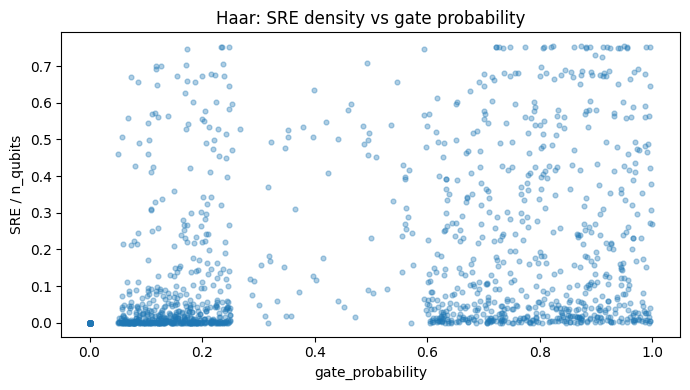

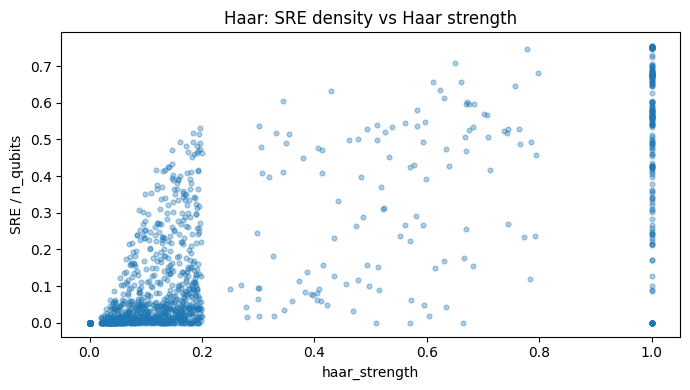

In [44]:
plot_haar_sre_controls(df_qubits)